# 第082课 概率与隐结构阶段项目

主项目：合成GMM真值、真实Wine边界、无混合负对照。另加解析共轭标量后验预测基准，与主GMM固定参数复制清楚分离。

In [1]:
import json, numpy as np
from pathlib import Path
from latent_project import *
from generate_data import make_data
from experiment import run
from IPython.display import display, Image
data=make_data()
print('真实特征:',data['wine_features'])
print('Wine划分:',{k:len(v['x']) for k,v in data['wine'].items()})
print('责任度手算:',np.array([.4*.2,.6*.1])/(.4*.2+.6*.1))

真实特征: ['alcohol', 'flavanoids']
Wine划分: {'train': 106, 'validation': 36, 'test': 36}
责任度手算: [0.57142857 0.42857143]


## 1 按验证密度选择，测试只评价

synthetic 候选: [{'k': 1, 'train_log_density': -2.8079496225830303, 'validation_log_density': -2.8423663210750214, 'training_bic': 3401.524195375717, 'converged': True, 'iterations': 2}, {'k': 2, 'train_log_density': -2.2011301449433502, 'validation_log_density': -2.256513731562287, 'training_bic': 2711.722400139398, 'converged': True, 'iterations': 11}, {'k': 3, 'train_log_density': -2.025368006243573, 'validation_log_density': -2.0724860399394665, 'training_bic': 2539.1894116309622, 'converged': True, 'iterations': 10}, {'k': 4, 'train_log_density': -2.0234168087450857, 'validation_log_density': -2.0734863229240084, 'training_bic': 2575.229552564074, 'converged': True, 'iterations': 149}]
选K 3 测试密度 -1.9957847006844442
wine 候选: [{'k': 1, 'train_log_density': -2.81347960822343, 'validation_log_density': -2.6310598010360566, 'training_bic': 619.7748724139275, 'converged': True, 'iterations': 2}, {'k': 2, 'train_log_density': -2.633591061560398, 'validation_log_density': -2.44940910256533,

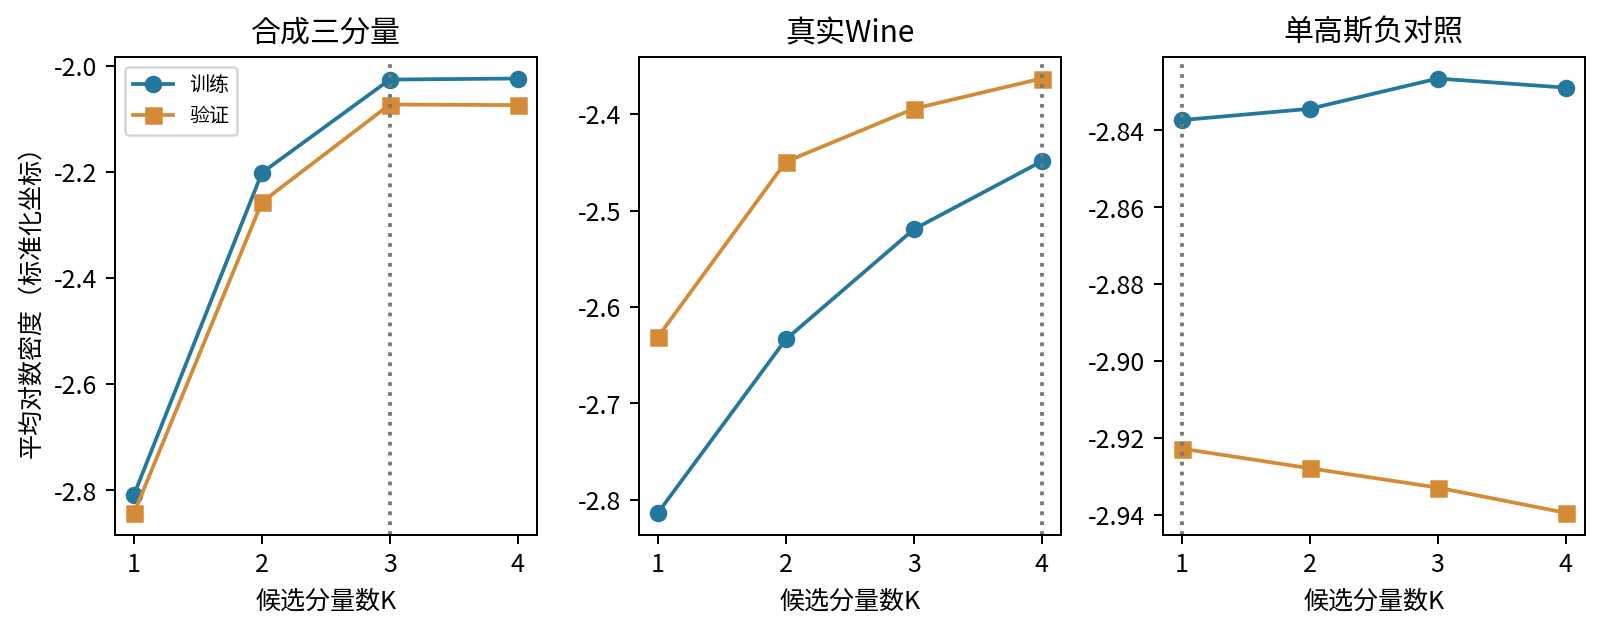

In [2]:
result,artifacts=run(True)
for name in ['synthetic','wine','negative']:
    print(name,'候选:',result[name]['candidates'])
    print('选K',result[name]['selected_k'],'测试密度',result[name]['test_log_density'])
display(Image(filename='figures/02_model_selection.png'))

合成ARI: 0.9845530430288947 均值恢复: {'estimated_order': [0, 1, 2], 'true_order': [2, 0, 1], 'matched_mean_rmse': 0.07759964566139985}
真参数测试密度: -1.958634535449984


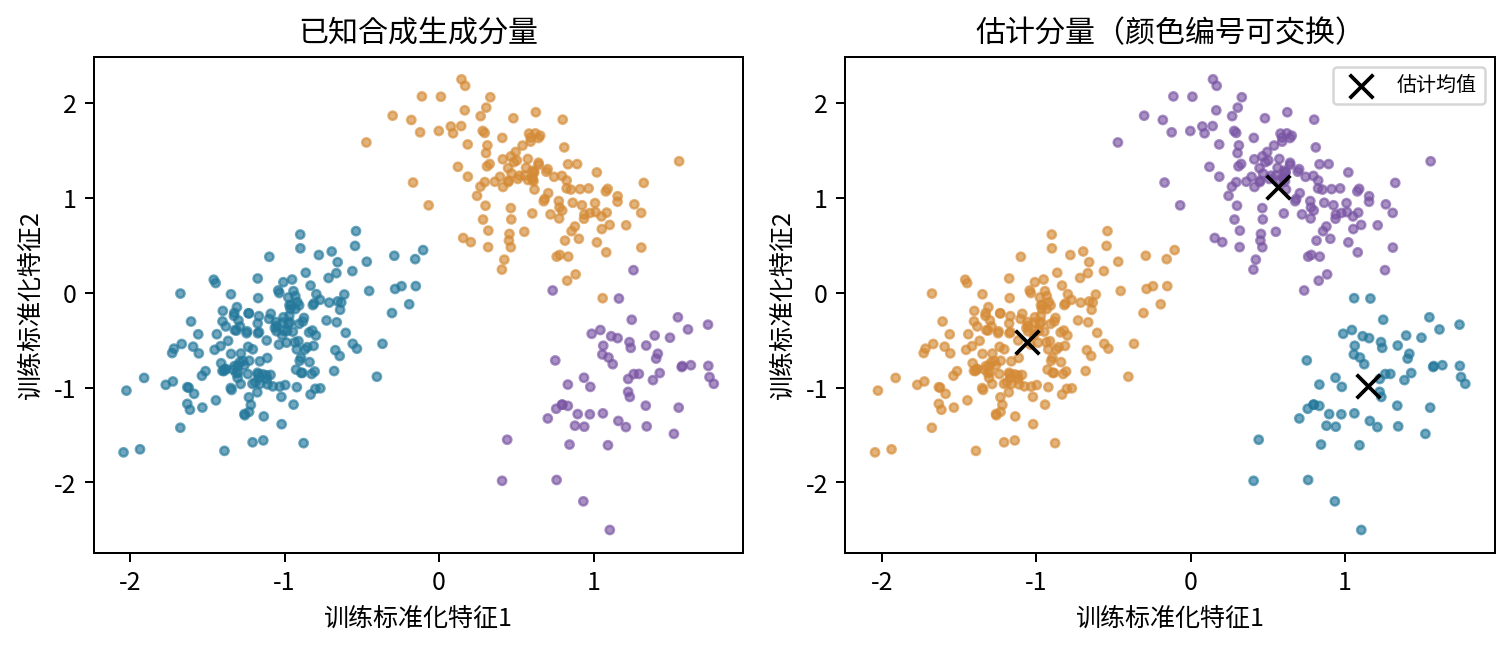

In [3]:
s=result['synthetic']
print('合成ARI:',s['truth_ari'],'均值恢复:',s['mean_recovery'])
print('真参数测试密度:',s['oracle_test_log_density'])
display(Image(filename='figures/01_truth_recovery.png'))

## 2 精确离散责任度与硬近似的可验缺口

synthetic 责任度误差 5.551115123125783e-16 log密度误差 1.7763568394002505e-15
硬q平均ELBO缺口 0.009260306297244881 平均熵 0.024663482064636998
wine 责任度误差 2.220446049250313e-16 log密度误差 8.881784197001252e-16
硬q平均ELBO缺口 0.07537415125138595 平均熵 0.17883915489540178
0.5/0.5硬化缺口: 0.6931471805599454


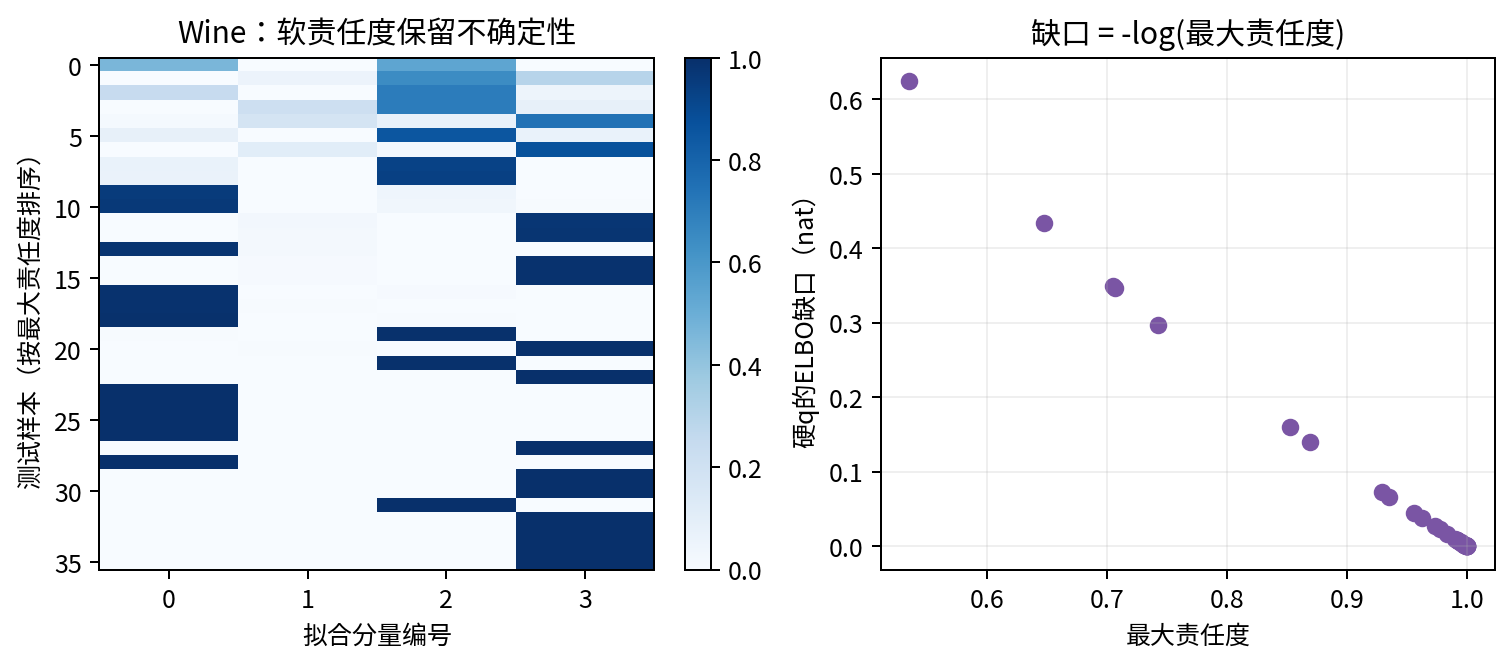

In [4]:
for name in ['synthetic','wine']:
    row=result[name]
    print(name,'责任度误差',row['responsibility_max_error'],'log密度误差',row['log_density_max_error'])
    print('硬q平均ELBO缺口',row['hard_q_mean_ELBO_gap'],'平均熵',row['mean_component_entropy'])
print('0.5/0.5硬化缺口:',hard_variational_gap([[-3,-3]])[0])
display(Image(filename='figures/03_responsibility_gap.png'))

synthetic restart_stability ARI范围 1.0 1.0
synthetic bootstrap_stability ARI范围 0.9896451911365184 1.0
wine restart_stability ARI范围 0.7311854554449323 1.0
wine bootstrap_stability ARI范围 0.6352774527314159 1.0


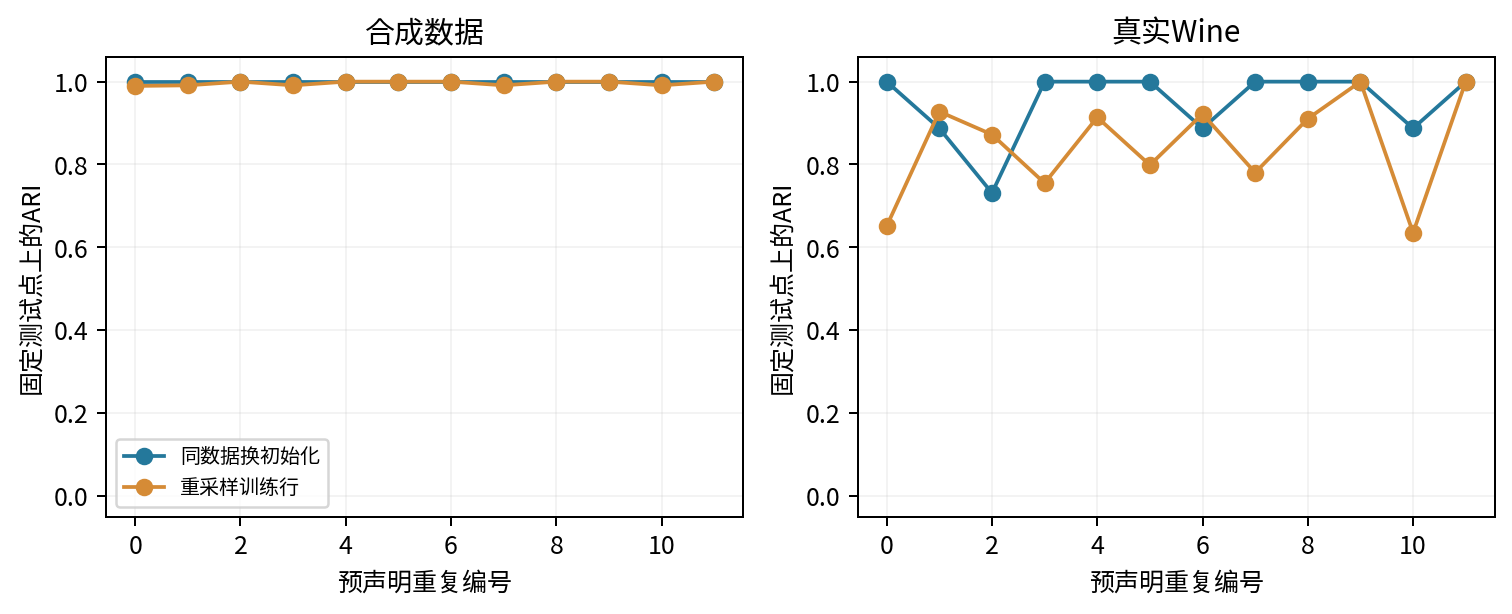

In [5]:
for name in ['synthetic','wine']:
    for kind in ['restart_stability','bootstrap_stability']:
        values=[r['ari_against_reference'] for r in result[name][kind]]
        print(name,kind,'ARI范围',min(values),max(values))
display(Image(filename='figures/04_stability.png'))

## 3 主GMM：固定参数复制，不是完整参数后验预测

synthetic {
  "correlation": {
    "observed": 0.37091317801548335,
    "replicate_interval95": [
      0.13921667794386522,
      0.31448621830219836
    ],
    "replicate_median": 0.2364545611971437,
    "outside_interval": true,
    "descriptive_tail_fraction": 0.004975124378109453
  },
  "tail_fraction": {
    "observed": 0.0225,
    "replicate_interval95": [
      0.01,
      0.0425
    ],
    "replicate_median": 0.025,
    "outside_interval": false,
    "descriptive_tail_fraction": 0.7562189054726368
  }
}
wine {
  "correlation": {
    "observed": 0.32963390535285686,
    "replicate_interval95": [
      -0.07019418064629838,
      0.5436747162398031
    ],
    "replicate_median": 0.2588811312404034,
    "outside_interval": false,
    "descriptive_tail_fraction": 0.6268656716417911
  },
  "tail_fraction": {
    "observed": 0.027777777777777776,
    "replicate_interval95": [
      0.0,
      0.1388888888888889
    ],
    "replicate_median": 0.027777777777777776,
    "outside_interv

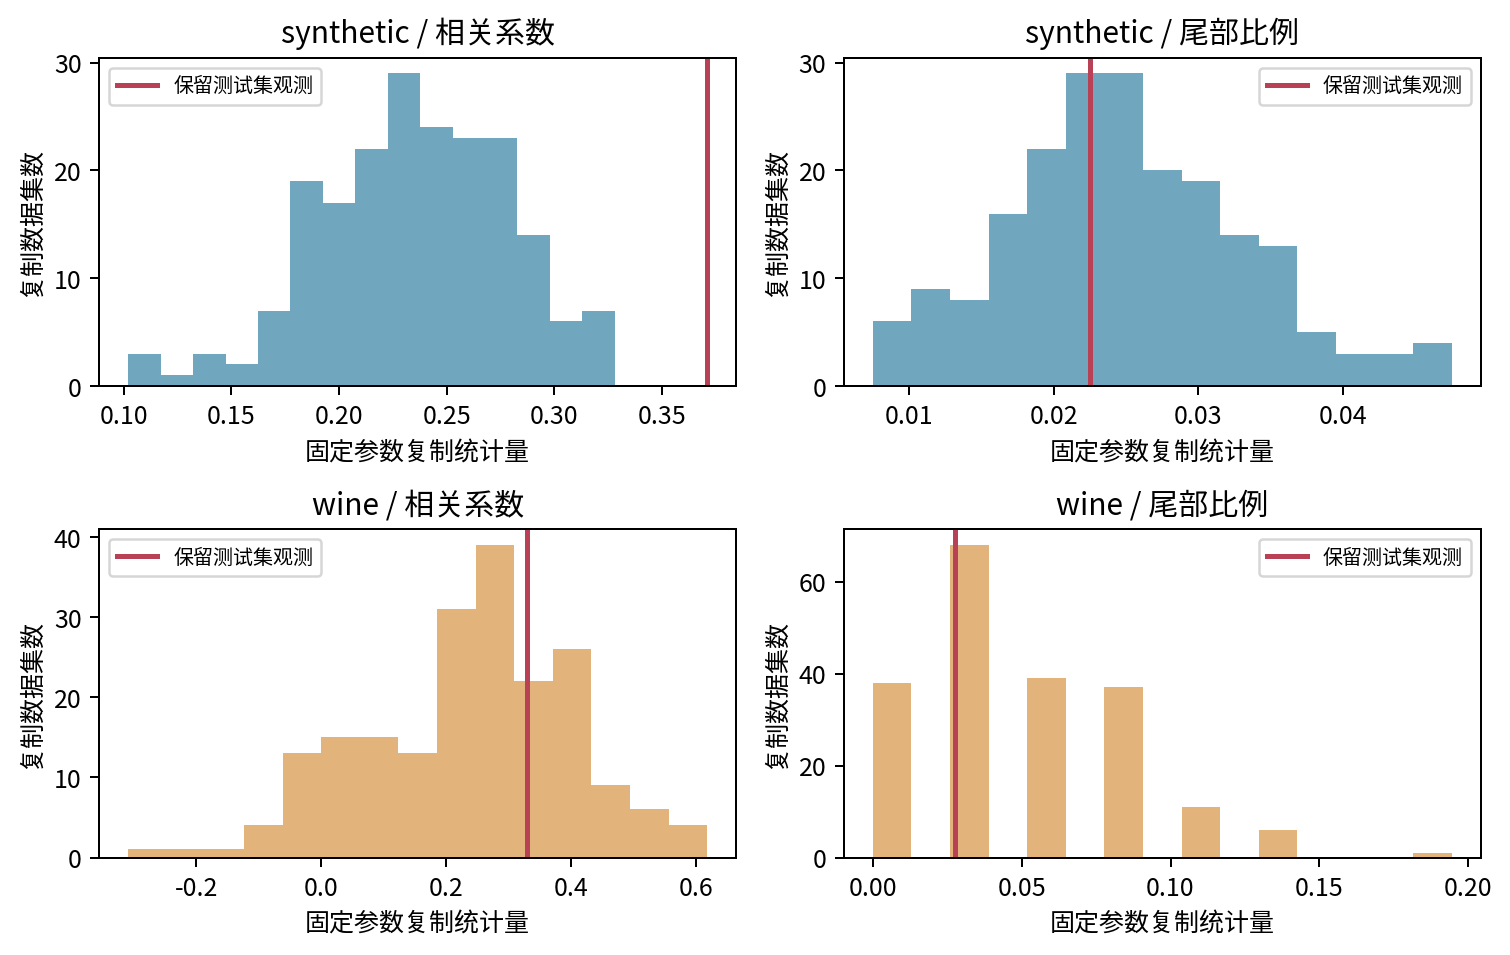

In [6]:
for name in ['synthetic','wine']:
    print(name,json.dumps(result[name]['fixed_parameter_predictive_check'],indent=2))
display(Image(filename='figures/05_predictive_checks.png'))
print('真实外部ARI:',result['wine']['external_cultivar_ari'],'分量占用:',result['wine']['test_component_counts'])

## 4 独立共轭基准：每份数据共享一次后验参数抽样

原始单高斯负对照第一维；噪声方差1已知，θ先验N(0,4)。此基准真正对参数后验积分，但不替代主GMM贝叶斯推断。

In [7]:
c=result['conjugate_posterior_predictive']
print(json.dumps(c,indent=2))
print('手算后验方差:',1/600.25)
print('复制均值方差：完整',1/600.25+1/400,'固定',1/400)
print('不能为同一份复制中的每个观测独立重抽theta。')

{
  "scope": "scalar normal mean with known variance 1; prior N(0,4); raw first feature of synthetic negative control only",
  "train_n": 600,
  "test_n": 400,
  "replicates": 5000,
  "posterior_mean": -0.02305035593198923,
  "posterior_variance": 0.001665972511453561,
  "observed_test_mean": -0.003293603739110671,
  "full_predictive_mean_variance_exact": 0.004165972511453561,
  "plugin_mean_variance_exact": 0.0025,
  "variance_ratio_exact": 1.6663890045814245,
  "full_predictive_mean_variance_mc": 0.004294394312473512,
  "plugin_mean_variance_mc": 0.002590985769259986,
  "full_predictive_mean_interval95_exact": [
    -0.14955494814465375,
    0.1034542362806753
  ],
  "plugin_mean_interval95_exact": [
    -0.12104855515899193,
    0.07494784329501347
  ],
  "full_predictive_mean_interval95_mc": [
    -0.14926757435547164,
    0.10520135538344978
  ]
}
手算后验方差: 0.001665972511453561
复制均值方差：完整 0.004165972511453561 固定 0.0025
不能为同一份复制中的每个观测独立重抽theta。


In [8]:
import unittest
from test_experiment import Checks
checks=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromTestCase(Checks))
if not checks.wasSuccessful():
    raise RuntimeError('unit tests failed')
print('实现与预声明实验验收完成，不代表真实隐结构已获证明。')

实现与预声明实验验收完成，不代表真实隐结构已获证明。


.................
----------------------------------------------------------------------
Ran 17 tests in 4.928s

OK


## 复盘

保留合成相关检查冲突、真实重采样不稳定与品种ARI1三个结果。它们回答不同问题，不能互相替代。